In [ ]:
# 安装 d2l 教程依赖包；--no-deps 表示不自动安装其依赖，--quiet 表示精简输出。
%pip install d2l --no-deps --quiet

In [ ]:
# 导入 PyTorch 主库，用于张量计算与深度学习训练。
import torch

# 从 torch 中导入神经网络模块，后续会用到损失函数和并行封装。
from torch import nn

# 导入 d2l 的 PyTorch 子模块，包含 BERTModel、计时器、可视化等教学工具。
from d2l import torch as d2l

# 以下代码用于在 Colab 中加载 BERT.py 和数据集，请根据实际情况修改路径。
# 从 Colab 导入 drive 模块，用于挂载 Google Drive。
from google.colab import drive

# 导入 os 模块，用于切换当前工作目录。
import os

# 导入 sys 模块，用于操作 Python 的模块搜索路径。
import sys

# 导入 Path 类，使用面向对象方式处理路径更安全直观。
from pathlib import Path

# 挂载 Google Drive 到 /content/drive；force_remount=False 表示若已挂载则不强制重挂载。
drive.mount('/content/drive', force_remount=False)

# 定义项目目录：这里假设代码位于 Colab Notebooks 下。
PROJECT_DIR = Path('/content/drive/MyDrive/Colab Notebooks')

# 拼接出 BERT.py 的完整路径。
BERT_FILE = PROJECT_DIR / 'BERT.py'

# 如果项目目录不存在，主动抛出异常并提示用户检查文件放置位置。
if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        f'目录不存在: {PROJECT_DIR}。请先把 ch14-NLP 文件夹放到 MyDrive/Colab Notebooks 下。'
    )

# 如果 BERT.py 不存在，也抛出异常并给出可操作提示。
if not BERT_FILE.exists():
    raise FileNotFoundError(
        f'未找到文件: {BERT_FILE}。请先上传 BERT.py 到该目录。'
    )

# 将当前工作目录切换到项目目录，便于后续相对路径读写。
os.chdir(PROJECT_DIR)

# 如果项目目录不在 Python 搜索路径中，则插入到最前面，确保优先导入本地模块。
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

# 从本地 BERT.py 中导入数据加载函数（本实验后续核心入口）。
from BERT import load_data_wiki

# 打印当前工作目录，便于确认路径配置是否正确。
print(f'当前工作目录: {PROJECT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
当前工作目录: /content/drive/MyDrive/Colab Notebooks


In [ ]:
# 设置批量大小 batch_size=512：每次迭代取 512 条训练样本。
batch_size = 512

# 设置序列最大长度 max_len=64：超过长度会被截断，不足会补齐。
max_len = 64

# 调用自定义的数据加载函数，返回训练迭代器 train_iter 和词表 vocab。
train_iter, vocab = load_data_wiki(batch_size, max_len)

In [ ]:
# 构建一个较小规模的 BERT 模型，便于教学演示与快速训练。
# 注意，新版D2L中BERTModel的参数有所调整，以下是基于最新版本的示例配置。
net = d2l.BERTModel(
    # 词表大小：决定词嵌入层可容纳的词元数量。
    vocab_size=len(vocab),
    # 隐藏层维度：Transformer 内部向量表示的长度。
    num_hiddens=128,
    # 前馈网络（FFN）中间层维度：通常大于 num_hiddens。
    ffn_num_hiddens=256,
    # 多头注意力头数：并行关注不同子空间信息。
    num_heads=2,
    # Transformer 编码块数量：层数越多，表达能力通常越强。
    num_blks=2,
    # Dropout 概率：训练时随机失活，降低过拟合风险。
    dropout=0.2,
    # 最大序列长度：需与数据处理阶段的 max_len 一致。
    max_len=max_len,
 )

# 检测当前可用设备（GPU/CPU）；若有多 GPU 会全部返回。
devices = d2l.try_all_gpus()

# 定义交叉熵损失函数，后续用于 MLM 和 NSP 两个任务。
loss = nn.CrossEntropyLoss()

In [ ]:
# 定义一个批次上的 BERT 训练损失计算函数。
# 该函数同时计算 MLM（遮蔽语言模型）与 NSP（下一句预测）两部分损失。
def _get_batch_loss_bert(net, loss, vocab_size, tokens_X,
                         segments_X, valid_lens_x,
                         pred_positions_X, mlm_weights_X,
                         mlm_Y, nsp_y):
    # 前向传播：输入词元、句段标记、有效长度、预测位置，得到编码输出与两类任务预测。
    _, mlm_Y_hat, nsp_Y_hat = net(tokens_X, segments_X,
                                  valid_lens_x.reshape(-1),
                                  pred_positions_X)

    # 计算 MLM 损失：
    # 1) 将预测结果 reshape 为 (样本数*预测位置数, 词表大小) 以匹配交叉熵输入格式；
    # 2) 将真实标签 reshape 为一维向量；
    # 3) 用 mlm_weights_X 对无效预测位置进行掩码加权。
    mlm_l = loss(mlm_Y_hat.reshape(-1, vocab_size), mlm_Y.reshape(-1)) *\
    mlm_weights_X.reshape(-1, 1)

    # 将所有有效位置的损失求和，再除以有效权重和，得到平均 MLM 损失。
    mlm_l = mlm_l.sum() / (mlm_weights_X.sum() + 1e-8)

    # 计算 NSP 损失：判断句子对是否为真实相邻句。
    nsp_l = loss(nsp_Y_hat, nsp_y)

    # 总损失为 MLM 与 NSP 之和。
    l = mlm_l + nsp_l

    # 返回三项损失，方便外部记录与反向传播。
    return mlm_l, nsp_l, l

In [ ]:
# 定义 BERT 训练函数。
def train_bert(train_iter, net, loss, vocab_size, devices, num_steps):
    """
    使用给定数据迭代器训练 BERT。
    参数说明：
    - train_iter: 训练数据迭代器，每次返回一个批次所需的全部张量。
    - net: BERT 模型实例。
    - loss: 损失函数（交叉熵）。
    - vocab_size: 词表大小，用于 MLM 预测维度对齐。
    - devices: 设备列表（如 [cuda:0, cuda:1] 或 [cpu]）。
    - num_steps: 计划训练的迭代步数。
    """
    # 使用 DataParallel 做多卡并行，并将模型放到主设备 devices[0]。
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])

    # 采用 Adam 优化器更新参数，学习率设为 0.01。
    trainer = torch.optim.Adam(net.parameters(), lr=0.01)

    # step 记录当前训练步数；timer 统计训练耗时。
    step, timer = 0, d2l.Timer()

    # 动态可视化损失曲线：横轴是 step，纵轴是 loss。
    animator = d2l.Animator(xlabel='step', ylabel='loss',
                            xlim=[1, num_steps], legend=['mlm', 'nsp'])

    # 累加器 metric 的 4 个槽位含义：
    # [0] MLM 损失累计值
    # [1] NSP 损失累计值
    # [2] 处理的句子对总数
    # [3] 已累计的批次数（用于计算平均损失）
    metric = d2l.Accumulator(4)

    # 标记是否达到目标步数（用于跳出双层循环）。
    num_steps_reached = False

    # 外层循环：当未达到 num_steps 时继续训练。
    while step < num_steps and not num_steps_reached:
        # 内层循环：逐批读取训练数据。
        for tokens_X, segments_X, valid_lens_x, pred_positions_X,\
            mlm_weights_X, mlm_Y, nsp_y in train_iter:
            # 将输入词元移动到主设备。
            tokens_X = tokens_X.to(devices[0])
            # 将句段标记移动到主设备。
            segments_X = segments_X.to(devices[0])
            # 将有效长度移动到主设备。
            valid_lens_x = valid_lens_x.to(devices[0])
            # 将 MLM 预测位置移动到主设备。
            pred_positions_X = pred_positions_X.to(devices[0])
            # 将 MLM 位置权重移动到主设备。
            mlm_weights_X = mlm_weights_X.to(devices[0])
            # 将 MLM 标签和 NSP 标签移动到主设备。
            mlm_Y, nsp_y = mlm_Y.to(devices[0]), nsp_y.to(devices[0])

            # 清空优化器中上一步残留的梯度。
            trainer.zero_grad()

            # 开始计时本批次训练时间。
            timer.start()

            # 前向计算并得到 MLM 损失、NSP 损失与总损失。
            mlm_l, nsp_l, l = _get_batch_loss_bert(
                net, loss, vocab_size, tokens_X, segments_X, valid_lens_x,
                pred_positions_X, mlm_weights_X, mlm_Y, nsp_y)

            # 反向传播：根据总损失计算参数梯度。
            l.backward()

            # 优化器执行一步参数更新。
            trainer.step()

            # 更新统计量：累计 MLM 损失、NSP 损失、样本数和批次数。
            metric.add(mlm_l, nsp_l, tokens_X.shape[0], 1)

            # 停止计时。
            timer.stop()

            # 将当前平均损失添加到动态图中。
            animator.add(step + 1,
                         (metric[0] / metric[3], metric[1] / metric[3]))

            # 步数加 1。
            step += 1

            # 达到目标步数后设置标记并跳出内层循环。
            if step == num_steps:
                num_steps_reached = True
                break

    # 训练结束后打印 MLM 和 NSP 的平均损失。
    print(f'MLM loss {metric[0] / metric[3]:.3f}, '
          f'NSP loss {metric[1] / metric[3]:.3f}')

    # 打印吞吐量：每秒处理多少句子对。
    print(f'{metric[2] / timer.sum():.1f} sentence pairs/sec on '
          f'{str(devices)}')

MLM loss 5.389, NSP loss 0.794
6065.5 sentence pairs/sec on [device(type='cuda', index=0)]


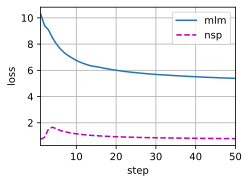

In [ ]:
# 调用训练函数开始预训练：
# - train_iter: 训练数据迭代器
# - net: BERT 模型
# - loss: 损失函数
# - len(vocab): 词表大小
# - devices: 计算设备列表
# - 50: 训练步数（教学示例，步数较小）
train_bert(train_iter, net, loss, len(vocab), devices, 50)

In [ ]:
# 定义一个工具函数：获取输入词元（单句或句对）的 BERT 编码表示。
def get_bert_encoding(net, tokens_a, tokens_b=None):
    """
    参数说明：
    - net: 已训练（或已初始化）的 BERT 模型。
    - tokens_a: 第一句的词元列表，例如 ['a', 'crane', 'is', 'flying']。
    - tokens_b: 第二句词元列表，默认为 None（表示单句任务）。
    返回值：
    - encoded_X: 形状为 (1, 序列长度, 隐藏维度) 的编码张量。
    """
    # 根据单句/句对构造带有 <cls>/<sep> 的词元序列与 segment 标记。
    tokens, segments = d2l.get_tokens_and_segments(tokens_a, tokens_b)

    # 将词元映射为词表索引，并转成形状为 (1, 序列长度) 的批量张量。
    token_ids = torch.tensor(vocab[tokens], device=devices[0]).unsqueeze(0)

    # 将 segment 列表转为张量，并增加 batch 维度。
    segments = torch.tensor(segments, device=devices[0]).unsqueeze(0)

    # 有效长度等于当前 tokens 的真实长度，同样增加 batch 维度。
    valid_len = torch.tensor(len(tokens), device=devices[0]).unsqueeze(0)

    # 前向计算得到编码结果；后两个返回值（mlm 与 nsp 输出）这里不使用。
    encoded_X, _, _ = net(token_ids, segments, valid_len)

    # 返回每个位置的上下文编码向量。
    return encoded_X

In [ ]:
# 定义单句词元序列。
tokens_a = ['a', 'crane', 'is', 'flying']

# 获取该单句输入经过 BERT 的编码结果。
encoded_text = get_bert_encoding(net, tokens_a)

# 对应词元序列为：'<cls>','a','crane','is','flying','<sep>'。
# 提取 <cls> 位置向量（常用于句级任务表示）。
encoded_text_cls = encoded_text[:, 0, :]

# 提取 'crane' 这个词元的位置向量（这里在索引 2）。
encoded_text_crane = encoded_text[:, 2, :]

# 打印：整体编码形状、<cls> 向量形状、'crane' 向量前 3 个维度值。
encoded_text.shape, encoded_text_cls.shape, encoded_text_crane[0][:3]

(torch.Size([1, 6, 128]),
 torch.Size([1, 128]),
 tensor([-0.5755, -0.0888,  1.2442], device='cuda:0', grad_fn=<SliceBackward0>))

In [ ]:
# 定义句子对：第一句 tokens_a，第二句 tokens_b。
tokens_a, tokens_b = ['a', 'crane', 'driver', 'came'], ['he', 'just', 'left']

# 获取句子对输入的 BERT 编码结果。
encoded_pair = get_bert_encoding(net, tokens_a, tokens_b)

# 对应词元序列为：
# '<cls>','a','crane','driver','came','<sep>','he','just','left','<sep>'。

# 提取句子对输入中的 <cls> 位置向量。
encoded_pair_cls = encoded_pair[:, 0, :]

# 提取词元 'crane'（索引 2）的位置向量。
encoded_pair_crane = encoded_pair[:, 2, :]

# 打印：句对编码形状、<cls> 向量形状、'crane' 向量前 3 个维度值。
encoded_pair.shape, encoded_pair_cls.shape, encoded_pair_crane[0][:3]

(torch.Size([1, 10, 128]),
 torch.Size([1, 128]),
 tensor([ 0.5182, -0.0111,  1.0603], device='cuda:0', grad_fn=<SliceBackward0>))